In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
import pandas as pd
import numpy as np 
import os
import re
import warnings
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV

In [4]:
import lightgbm as lgb
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from scipy.sparse import csr_matrix, hstack
from tqdm import tqdm


In [5]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet',quiet = True)
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
RANDOM_STATE=42

In [6]:
train_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
print(train_df.head())

                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright

In [7]:
print(train_df.head())
print(train_df.info())
print(train_df.describe())

                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-01-18 08:43:57.397508+00:00       73           0           0   
1  2024-03-24 21:43:11.490017+00:00       39           0           0   
2  2024-04-24 20:32:17.014931+00:00       31           0           1   
3  2023-05-28 22:00:14.214527+00:00       39           0           0   
4  2023-09-09 23:12:05.689498+00:00       39           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       0         1     0    10  NaN      NaN    NaN       False   
1           0       6         0     0     4  NaN      NaN    NaN       False   
2           1       0         0     0    10  NaN      NaN    NaN       False   
3           0       5         0     0    10  NaN      NaN    NaN       False   
4           0       0         0     0    10  NaN      NaN    NaN       False   

                                             comment  label  
0  She might be a bright

In [8]:
print(train_df.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


In [9]:
test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [10]:
print(test_df.head())
print(test_df.info())
print(test_df.describe)



                       created_date  post_id  emoticon_1  emoticon_2  \
0  2024-02-08 13:13:27.998156+00:00       72           2           0   
1  2024-03-01 23:33:25.547123+00:00      123           0           0   
2  2024-02-09 21:52:48.426303+00:00      120           0           0   
3  2024-02-17 03:43:02.980294+00:00      123           0           0   
4  2024-04-24 02:27:57.145155+00:00      123           0           0   

   emoticon_3  upvote  downvote  if_1  if_2 race religion gender  disability  \
0           0       4         1     0    10  NaN      NaN    NaN       False   
1           0       0         0     0    10  NaN      NaN    NaN       False   
2           0       3         0     0     4  NaN      NaN    NaN       False   
3           0       0         0     0     4  NaN      NaN    NaN       False   
4           0       0         0     0    11  NaN      NaN    NaN       False   

                                             comment  
0  Canada is being run by someo

In [11]:
print(test_df.isnull().sum())

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


In [12]:
num_features = ['upvote','downvote','if_1','if_2']
binary_features = ['emoticon_1','emoticon_2','emoticon_3','disability']
cat_features = ['race','religion','gender']
datetime_features = ['created_date']
text_features = ['comment']
target = ['label']

In [13]:
print('Numeric:', num_features)
print('Binary:', binary_features)
print('Categorical:', cat_features)
print('Datetime:', datetime_features)
print('Text:', text_features)
print('Target:', target)

Numeric: ['upvote', 'downvote', 'if_1', 'if_2']
Binary: ['emoticon_1', 'emoticon_2', 'emoticon_3', 'disability']
Categorical: ['race', 'religion', 'gender']
Datetime: ['created_date']
Text: ['comment']
Target: ['label']


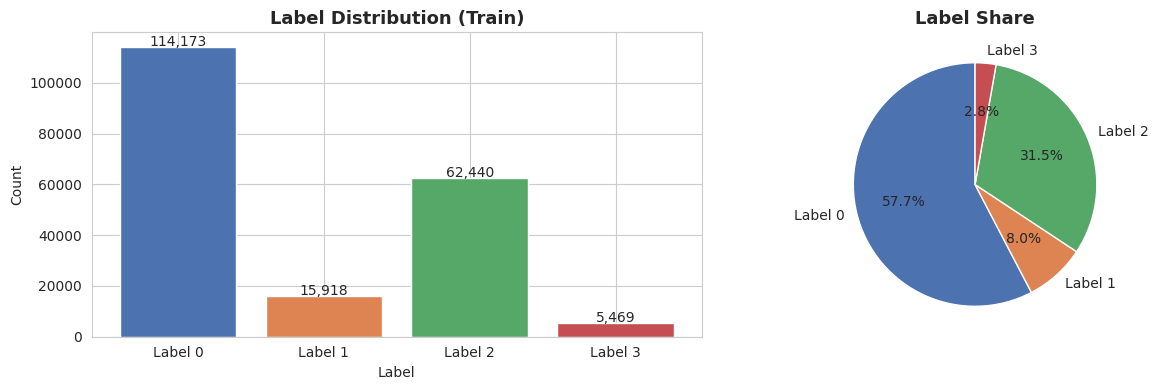


 INSIGHT: Class imbalance detected!
Label 0 dominates at  57.7% of samples.
Label 3 is the minority class at only  2.8%.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts = train_df['label'].value_counts().sort_index()

axes[0].bar(range(len(label_counts)), label_counts.values,
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels([f'Label {i}' for i in label_counts.index], fontsize=10)
axes[0].set_title('Label Distribution (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(label_counts.values, labels=[f'Label {i}' for i in label_counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('Label Share', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
dominant = label_counts.idxmax()
dominant_pct = label_counts.max()/label_counts.sum()*100
minority = label_counts.idxmin()
minority_pct = label_counts.min()/label_counts.sum() * 100
print(f'\n INSIGHT: Class imbalance detected!')
print(f'Label {dominant} dominates at {dominant_pct: .1f}% of samples.')
print(f'Label {minority} is the minority class at only {minority_pct: .1f}%.')

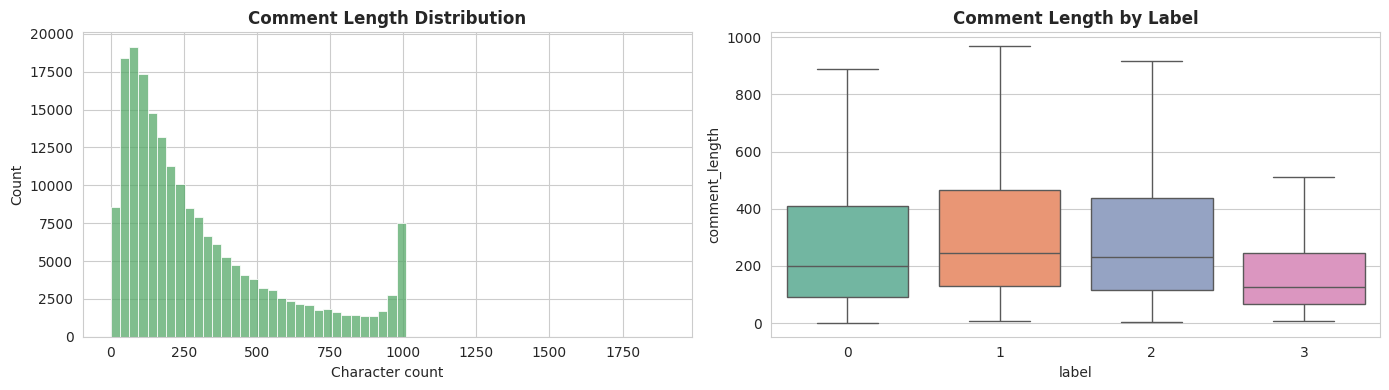


 INSIGHT: Comment length varies meaningfully across labels - useful feature.


In [15]:
train_df['comment_length'] = train_df['comment'].fillna(" ").apply(len)
fig,axes = plt.subplots(1,2,figsize=(14,4))
sns.histplot(train_df['comment_length'], bins=60, ax=axes[0], color = '#55A868')
axes[0].set_title('Comment Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character count')
sns.boxplot(x = 'label', y='comment_length', data = train_df, ax = axes[1], palette = 'Set2', showfliers=False)
axes[1].set_title('Comment Length by Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n INSIGHT: Comment length varies meaningfully across labels - useful feature.')

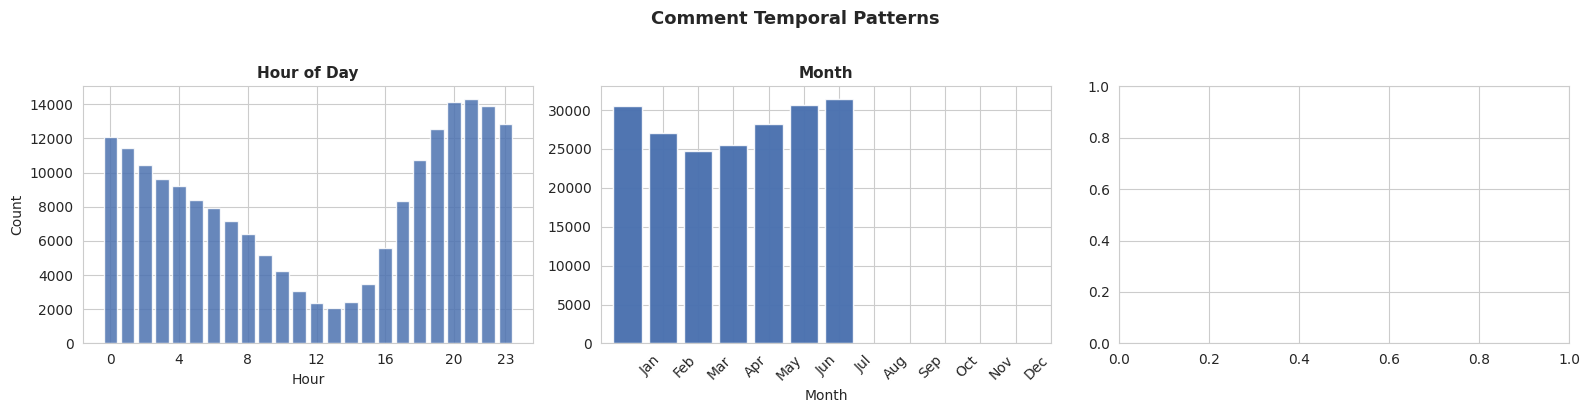


 INSIGHT: Comments peak in late evening hours and are fairly spread across weekdays.


In [16]:
tmp = train_df.copy()
tmp['created_date'] = pd.to_datetime(tmp['created_date'])
tmp['hour'] = tmp['created_date'].dt.hour
tmp['day_of_week'] = tmp['created_date'].dt.dayofweek
tmp['month'] = tmp['created_date'].dt.month

fig,axes = plt.subplots(1,3,figsize=(16,4))
hour_counts = tmp['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color = '#4C72B0', alpha=0.85)
axes[0].set_xticks([0,4,8,12,16,20,23])
axes[0].set_xticklabels(['0','4','8','12','16','20','23'])
axes[0].set_title('Hour of Day', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Count')

day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = tmp['day_of_week'].value_counts().sort_index()
axes[1].bar(day_counts.index, day_counts.values, color = '#4C72B0', alpha = 0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title('Day of week', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Day')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul', 'Aug', 'Sep','Oct', 'Nov', 'Dec']
month_counts = tmp['month'].value_counts().sort_index()
axes[1].bar(day_counts.index, day_counts.values, color = '#4C72B0', alpha = 0.85)
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(month_labels, rotation=45, ha='right')
axes[1].set_title('Month', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Month')

plt.suptitle('Comment Temporal Patterns', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('\n INSIGHT: Comments peak in late evening hours and are fairly spread across weekdays.')



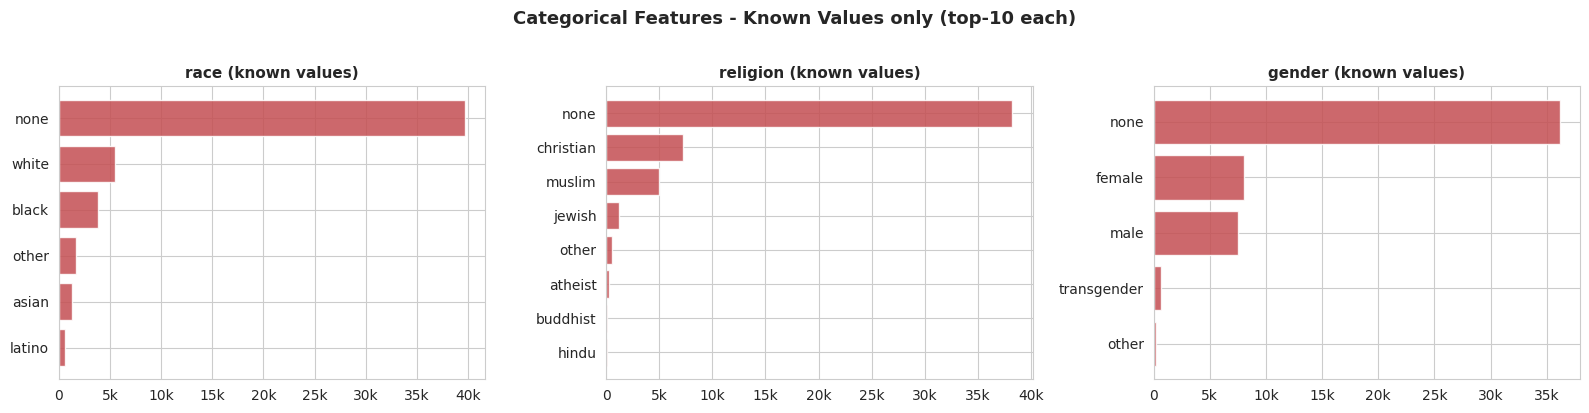


 INSIGHT:  73.4% of race/region/gender values are missing.
Among known values, the distribution is shown above.


In [17]:
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, col in zip(axes, ['race','religion','gender']):
    vc = train_df[col].dropna()
    vc = vc[vc.str.lower() != 'unknown'].value_counts().head(10)
    if len(vc) == 0:
        ax.text(0.5,0.5,'All values\n are missing', ha='center', va='center', transform = ax.transAxes, fontsize=11)
    else:
        ax.barh(vc.index[::-1], vc.values[::-1], color='#C44E52', alpha=0.85)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
    ax.set_title(f'{col} (known values)', fontsize=11,fontweight='bold')
    plt.suptitle('Categorical Features - Known Values only (top-10 each)', fontsize=13, fontweight='bold', y= 1.02)
plt.tight_layout()
plt.show()

total = len(train_df)
missing_pct = train_df['race'].isna().sum() / total * 100
print(f'\n INSIGHT: {missing_pct: .1f}% of race/region/gender values are missing.')
print('Among known values, the distribution is shown above.')
    

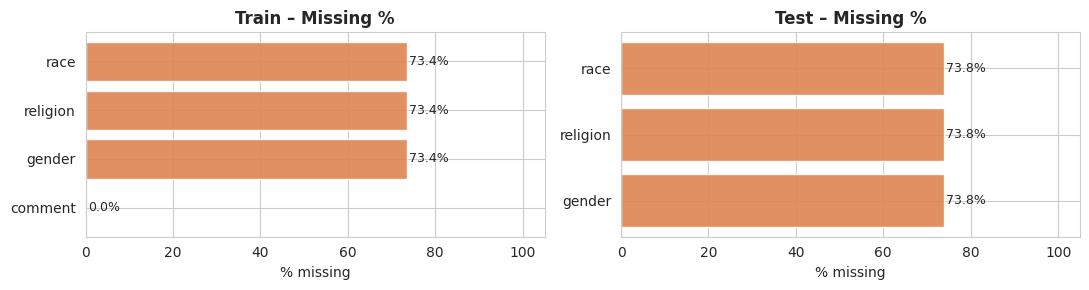

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, df, title in [(axes[0], train_df, 'Train'), (axes[1], test_df, 'Test')]:
    expected_cols = ['created_date','post_id','emoticon_1','emoticon_2','emoticon_3',
                     'upvote','downvote','if_1','if_2','race','religion','gender',
                     'disability','comment','label']
    df_clean = df[[c for c in expected_cols if c in df.columns]]
    missing = df_clean.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
    else:
        ax.barh(missing.index[::-1], missing.values[::-1], color='#DD8452', alpha=0.9)
        for j, (val, name) in enumerate(zip(missing.values[::-1], missing.index[::-1])):
            ax.text(val + 0.5, j, f'{val:.1f}%', va='center', fontsize=9)
    ax.set_title(f'{title} – Missing %', fontsize=12, fontweight='bold')
    ax.set_xlabel('% missing')
    ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()


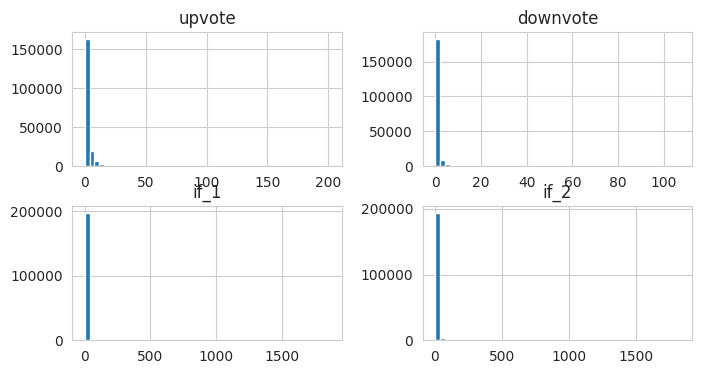

In [19]:
num_col = ['upvote','downvote','if_1','if_2']
train_df[num_col].hist(bins=50, figsize=(8,4))
plt.show()

In [20]:
binary = ['emoticon_1','emoticon_2','emoticon_3','race','religion','gender','disability']
for col in binary:
    print(train_df[col].value_counts())

emoticon_1
0     169078
1      17683
2       5799
3       2362
4       1243
5        638
6        374
7        225
8        162
9        102
10        69
11        68
12        40
13        27
15        20
16        20
14        19
19        13
17         9
23         7
22         6
20         5
18         5
36         4
25         4
27         3
24         2
21         2
31         2
30         2
32         2
28         1
46         1
33         1
47         1
39         1
Name: count, dtype: int64
emoticon_2
0     189891
1       7031
2        822
3        177
4         48
5         21
6          7
8          1
11         1
7          1
Name: count, dtype: int64
emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: int64
race
none      39682
white      5486
black      3869
other      1654
asian      126

 > # **PREPROCESSING:**
* Missing data detection and imputation
* Scaling numerical features
* Encoding categorical features

In [21]:
df = pd.concat([train_df,test_df] ,axis=0, ignore_index=True)
df['comment'] = df['comment'].fillna('')

In [22]:
print(f'Combined shape: {df.shape}')
print('Missing values: ')
print(df.isnull().sum()[df.isnull().sum() >0])

Combined shape: (300000, 16)
Missing values: 
race              220692
religion          220692
gender            220692
label             102000
comment_length    102000
dtype: int64


In [23]:
df["created_date"] = pd.to_datetime(df['created_date'])
df['hour'] = df['created_date'].dt.hour
df['day_of_week'] = df['created_date'].dt.dayofweek
df['month'] = df['created_date'].dt.month
df['year'] = df['created_date'].dt.year
df['is_weekend'] = (df['day_of_week'] >=5).astype(int)

In [24]:
impute_cols = ['race','religion','gender']
for col in impute_cols:
    df[col].fillna('Unknown', inplace=True)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
print('Categorical encoding done: ',{c: df[c].nunique() for c in impute_cols})

Categorical encoding done:  {'race': 7, 'religion': 9, 'gender': 6}


In [25]:
df['raw_upvote'] = df['upvote'].copy()
df['raw_downvote'] = df['downvote'].copy()
numeric_cols = ['upvote','downvote','if_1','if_2']
for col in numeric_cols:
    df[col] = np.log1p(df[col])
df['disability'] = df['disability'].astype(int)

 > # **FEATURE ENGINEERING**

In [26]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text,str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)  
    text = re.sub(r'\d+', ' num ', text)               
    text = re.sub(r'[^\w\s]', ' ', text)  
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)
df['clean_comment'] = df['comment'].apply(preprocess_text)

In [27]:
post_counts = df.groupby('post_id')['post_id'].transform('count')
df['post_comment_count'] = post_counts
df['comment_length'] = df['comment'].apply(lambda x: len(str(x)))
df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
df['avg_word_length'] = df['comment'].apply(lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0)
df['vote_ratio'] = df['upvote']/(df['upvote'] + df['downvote']+1)
df['total_emoticons'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']
df['has_emoticon'] = (df['total_emoticons'] >0).astype(int)
df['exclaim_count'] = df['comment'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['comment'].apply(lambda x: str(x).count('?'))
df['url_count'] = df['comment'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['punct_count'] = df['comment'].apply(lambda x: sum(1 for c in str(x) if c in '!?.,;:'))
df['unique_word_ratio'] = df['comment'].apply(lambda x: len(set(str(x).lower().split())) / max(len(str(x).split()),1))
df['upper_ratio'] = df['comment'].apply(lambda x: sum(1 for c in str(x) if c.isupper())/ max(len(str(x)),1))
print('Engineered features added:')
eng_fea = ['comment_length','word_count','avg_word_length','vote_ratio','total_emoticons',
         'has_emoticon','exclaim_count','post_comment_count','punct_count','unique_word_ratio', 'question_count','url_count','upper_ratio']
print(df[eng_fea].describe().T[['mean','std','min','max']])

Engineered features added:
                            mean           std  min            max
comment_length        302.852617    266.152127  0.0    1892.000000
word_count             52.402213     45.734946  0.0     315.000000
avg_word_length         4.908990      3.325046  0.0     999.000000
vote_ratio              0.295322      0.259898  0.0       0.839924
total_emoticons         0.448550      1.259682  0.0      97.000000
has_emoticon            0.226720      0.418711  0.0       1.000000
exclaim_count           0.224603      0.976040  0.0      96.000000
post_comment_count  60205.729133  37168.697722  1.0  105551.000000
punct_count             6.776033      6.465567  0.0     244.000000
unique_word_ratio       0.868431      0.106048  0.0       1.000000
question_count          0.440337      0.984725  0.0      49.000000
url_count               0.030073      0.210561  0.0      15.000000
upper_ratio             0.035425      0.042688  0.0       1.000000


In [28]:
scaler = StandardScaler()
all_numeric_cols = ['upvote','downvote','if_1','if_2', 'comment_length',
                    'word_count','avg_word_length','vote_ratio',
                    'total_emoticons','exclaim_count','question_count',
                    'url_count','upper_ratio','hour', 'day_of_week','month','year']
df[all_numeric_cols] = scaler.fit_transform(df[all_numeric_cols])
print('Scaling applied to', len(all_numeric_cols), 'numeric columns.')


Scaling applied to 17 numeric columns.


> # **PIPELINE CONSTRUCTION**

In [29]:
train_data = df[df['label'].notna()].copy()
test_data = df[df['label'].isna()].copy()

In [30]:
from sklearn.model_selection import KFold
n_labels = 4
kf  =KFold(n_splits=5, shuffle=True, random_state=42)
y_train = train_data['label'].astype(int).values
post_ids_train = train_data['post_id'].values

In [31]:
for k in range(n_labels):
    train_data[f'post_label{k}_ratio'] = 0.0

In [32]:
for tr_idx, vl_idx in kf.split(train_data):
    tr_slice = train_data.iloc[tr_idx]
    for k in range(n_labels):
        post_k_mean = tr_slice.groupby('post_id')['label'].apply(lambda x: (x==k).mean())
        global_mean_k = (y_train[tr_idx] == k).mean()
        train_data.iloc[vl_idx, train_data.columns.get_loc(f'post_label{k}_ratio')] = (
            train_data.iloc[vl_idx]['post_id'].map(post_k_mean).fillna(global_mean_k)
        )

In [33]:
for k in range(n_labels):
    post_k_mean_full = train_data.groupby('post_id')['label'].apply(lambda x: (x==k).mean())
    global_mean_k = (y_train == k).mean()
    test_data[f'post_label{k}_ratio'] = (test_data['post_id'].map(post_k_mean_full).fillna(global_mean_k))
    print('post-level target encoding done.')
    print('New features:',  [f'post_label{k}_ratio' for k in range(n_labels)])

post-level target encoding done.
New features: ['post_label0_ratio', 'post_label1_ratio', 'post_label2_ratio', 'post_label3_ratio']
post-level target encoding done.
New features: ['post_label0_ratio', 'post_label1_ratio', 'post_label2_ratio', 'post_label3_ratio']
post-level target encoding done.
New features: ['post_label0_ratio', 'post_label1_ratio', 'post_label2_ratio', 'post_label3_ratio']
post-level target encoding done.
New features: ['post_label0_ratio', 'post_label1_ratio', 'post_label2_ratio', 'post_label3_ratio']


In [34]:
feature_cols = all_numeric_cols+ impute_cols+ ['disability','has_emoticon','total_emoticons','is_weekend','emoticon_1','emoticon_2','emoticon_3']
feature_cols = list(dict.fromkeys(feature_cols))
X = train_data[feature_cols].values.astype(np.float64)
y = train_data['label'].astype(int)
X_test = test_data[feature_cols].values.astype(np.float64)

In [35]:
print(f'X shape: {X.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y distribution: \n{y.value_counts().sort_index()}')

X shape: (198000, 26)
X_test shape: (102000, 26)
y distribution: 
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64


In [36]:
word_tfidf = TfidfVectorizer(max_features= 50000,ngram_range = (1,3), sublinear_tf = True, min_df=3, max_df=0.95)
word_tfidf.fit(train_data['clean_comment'])
X_word_tr = word_tfidf.transform(train_data['clean_comment'])
X_word_te = word_tfidf.transform(test_data['clean_comment'])

In [37]:
char_tfidf = TfidfVectorizer(max_features=20000,ngram_range = (3,5), sublinear_tf = True, min_df=3, analyzer='char_wb')
char_tfidf.fit(train_data['clean_comment'].fillna(''))
X_char_tr = char_tfidf.transform(train_data['comment'].fillna(''))
X_char_te = char_tfidf.transform(test_data['comment'].fillna(''))

In [38]:
X_num_tr = csr_matrix(X)
X_num_te = csr_matrix(X_test)

In [39]:
X_train_final = hstack([X_word_tr,X_char_tr,X_num_tr])
X_test_final = hstack([X_word_te,X_char_te,X_num_te])

In [40]:
print(f'Combined train features: {X_train_final.shape}')
print(f'Combined test features: {X_test_final.shape}')

Combined train features: (198000, 70026)
Combined test features: (102000, 70026)


> # **MODEL COMPARISION**

In [41]:
from sklearn.model_selection import StratifiedShuffleSplit
sss= StratifiedShuffleSplit(n_splits=1, test_size=0.97, random_state = RANDOM_STATE)
sub_idx, _ = next(sss.split(X_train_final,y))
X_sub = X_train_final[sub_idx]
y_sub = y.iloc[sub_idx]
print(f'Subsample size: {X_sub.shape[0]:,} (3% of train)')

Subsample size: 5,940 (3% of train)


In [42]:
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
comparision_models = {
    'Logistic Regression': LogisticRegression(C=1.0,max_iter=500,solver='saga', multi_class='multinomial',random_state=RANDOM_STATE, n_jobs=-1),
    'Linear SVC': CalibratedClassifierCV(LinearSVC(C=0.1,max_iter=1000,random_state=RANDOM_STATE)),
    'LightGBM (default)': lgb.LGBMClassifier(objective='multiclass',num_class=4,n_estimators=100,learning_rate=0.1,num_leaves=31,subsample=0.8,colsample_bytree=0.8,reg_leaves=0.1,reg_alpha=0.05,random_state=RANDOM_STATE,verbose=-1,n_jobs=-1)
}


In [43]:
model_results={}
for name, model in comparision_models.items():
    fold_accs = []
    fold_f1s = []
    for tr_idx, val_idx in skf.split(X_sub,y_sub):
        xtr, xvl = X_sub[tr_idx],X_sub[val_idx]
        ytr, yvl = y_sub.iloc[tr_idx], y_sub.iloc[val_idx]
        model.fit(xtr,ytr)
        preds = model.predict(xvl)
        fold_accs.append(accuracy_score(yvl,preds))
        fold_f1s.append(f1_score(yvl,preds,average='weighted'))
    model_results[name] = {
        'acc_mean': np.mean(fold_accs),
        'acc_std' : np.std(fold_accs),
        'f1_mean': np.mean(fold_f1s),
        'f1_std': np.std(fold_f1s)
    }
    print(f"{name:35s}  Acc={np.mean(fold_accs):.4f}±{np.std(fold_accs):.4f}  "
          f"F1={np.mean(fold_f1s):.4f}±{np.std(fold_f1s):.4f}")

Logistic Regression                  Acc=0.8734±0.0010  F1=0.8629±0.0011
Linear SVC                           Acc=0.8739±0.0002  F1=0.8621±0.0008
LightGBM (default)                   Acc=0.8854±0.0019  F1=0.8766±0.0020


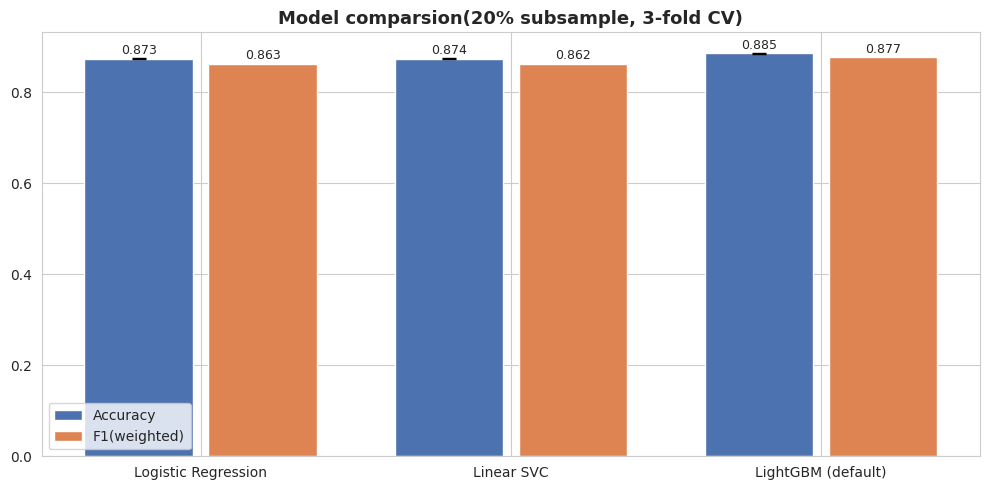


 Best model on subsample: LightGBM (default)
Proceeding with LightGBM (full data, tuned hyperparameters)


In [44]:
names = list(model_results.keys())
accs = [model_results[n]['acc_mean'] for n in names]
f1s = [model_results[n]['f1_mean'] for n in names]
acc_err = [model_results[n]['acc_std'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10,5))
bars1 = ax.bar(x-0.2, accs, 0.35, label='Accuracy', color = '#4C72B0', yerr= acc_err, capsize=5)
bars2 = ax.bar(x+0.2, f1s, 0.35, label = 'F1(weighted)', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_title('Model comparsion(20% subsample, 3-fold CV)', fontsize=13, fontweight='bold')
ax.legend()
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                         f'{bar.get_height():.3f}', ha='center',fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                         f'{bar.get_height():.3f}', ha='center',fontsize=9)
plt.tight_layout()
plt.show()
best_model_name = max(model_results, key= lambda n: model_results[n]['acc_mean'])
print(f'\n Best model on subsample: {best_model_name}')
print('Proceeding with LightGBM (full data, tuned hyperparameters)')

> # **HYPERPARAMETER TUNING**

In [45]:
from itertools import product
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.97, random_state=RANDOM_STATE)
tune_idx, _ = next(sss2.split(X_train_final,y))
X_tune = X_train_final[tune_idx]
y_tune = y.iloc[tune_idx]
print(f'Tuning subsample: {X_tune.shape[0]:,} rows')
param_grid= [
    {'num_leaves': 31,  'learning_rate': 0.1,  'n_estimators': 200},
    {'num_leaves': 63, 'learning_rate': 0.1,  'n_estimators': 200},
    {'num_leaves': 63,  'learning_rate': 0.05, 'n_estimators': 300}
]
best_score=0 
best_params = param_grid[0]
skf2 = StratifiedKFold(n_splits=2, shuffle = True, random_state=RANDOM_STATE)
for params in param_grid:
    scores = []
    for tr_i, vl_i in skf2.split(X_tune, y_tune):
        m = lgb.LGBMClassifier(
            objective='multiclass', num_class=4,
            num_leaves=params['num_leaves'],
            learning_rate=params['learning_rate'],
            n_estimators=params['n_estimators'],
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=0.1, reg_alpha=0.05,
            random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
        m.fit(X_tune[tr_i], y_tune.iloc[tr_i])
        scores.append(accuracy_score(y_tune.iloc[vl_i], m.predict(X_tune[vl_i])))
    mean_score = np.mean(scores)
    if mean_score> best_score:
        best_score = mean_score
        best_params = params
    print(f'{params} -> acc={mean_score:.4f}')
print(f'\n Best params: {best_params} (CV acc= {best_score:.4f})')

Tuning subsample: 5,940 rows
{'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 200} -> acc=0.8870
{'num_leaves': 63, 'learning_rate': 0.1, 'n_estimators': 200} -> acc=0.8848
{'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 300} -> acc=0.8867

 Best params: {'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 200} (CV acc= 0.8870)


> # **GroupKFold TRAINING WITH TUNED LightGBM**

In [46]:
BEST_PARAMS = {
    'objective'       : 'multiclass',
    'num_class'       : 4,
    'n_estimators'    : 1000,          
    'learning_rate'   : 0.05,
    'num_leaves'      : 127,
    'subsample'       : 0.8,
    'colsample_bytree': 0.6,
    'reg_lambda'      : 0.2,
    'reg_alpha'       : 0.05,
    'min_child_samples': 30,
    'random_state'    : RANDOM_STATE,
    'verbose'         : -1,
    'n_jobs'          : -1,
}

In [47]:
N_FOLDS = 5
gkf = GroupKFold(n_splits= N_FOLDS)
groups= train_data['post_id'].values

In [48]:
val_preds = np.zeros(len(y))
test_preds = np.zeros((X_test_final.shape[0],4))
fold_scores = []

In [49]:
print('Starting cross-validation:')
for fold, (tr_idx, vl_idx) in enumerate(gkf.split(X_train_final,y, groups=groups)):
    print(f'Fold {fold+1}/5')
    X_tr= X_train_final[tr_idx]
    y_tr= y.iloc[tr_idx]
    X_val= X_train_final[vl_idx]
    y_val= y.iloc[vl_idx]
    sw = compute_sample_weight(class_weight='balanced',y=y_tr)
    model = lgb.LGBMClassifier(**BEST_PARAMS)
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_val, y_val)],
             callbacks = [lgb.early_stopping(50,verbose=False), lgb.log_evaluation(100)])
    vl_proba = model.predict_proba(X_val)
    val_preds[vl_idx] = vl_proba.argmax(axis=1)
    fold_acc = accuracy_score(y_val, val_preds[vl_idx])
    fold_scores.append(fold_acc)
    test_preds += model.predict_proba(X_test_final)
test_preds /= N_FOLDS
final_predictions = test_preds.argmax(axis=1)

Starting cross-validation:
Fold 1/5
[100]	valid_0's multi_logloss: 0.290855
[200]	valid_0's multi_logloss: 0.267776
[300]	valid_0's multi_logloss: 0.268093
Fold 2/5
[100]	valid_0's multi_logloss: 0.28694
[200]	valid_0's multi_logloss: 0.256978
[300]	valid_0's multi_logloss: 0.252193
Fold 3/5
[100]	valid_0's multi_logloss: 0.316895
[200]	valid_0's multi_logloss: 0.283206
[300]	valid_0's multi_logloss: 0.277106
Fold 4/5
[100]	valid_0's multi_logloss: 0.287088
[200]	valid_0's multi_logloss: 0.257099
[300]	valid_0's multi_logloss: 0.251155
Fold 5/5
[100]	valid_0's multi_logloss: 0.30025
[200]	valid_0's multi_logloss: 0.268502
[300]	valid_0's multi_logloss: 0.262309


In [50]:
cv_accuracy = accuracy_score(y, val_preds)
print(f"Cross-val Accuracy: {cv_accuracy:.4f}")

Cross-val Accuracy: 0.9155


> # **FEATURE IMPORTANCE & KEY INSIGHTS**

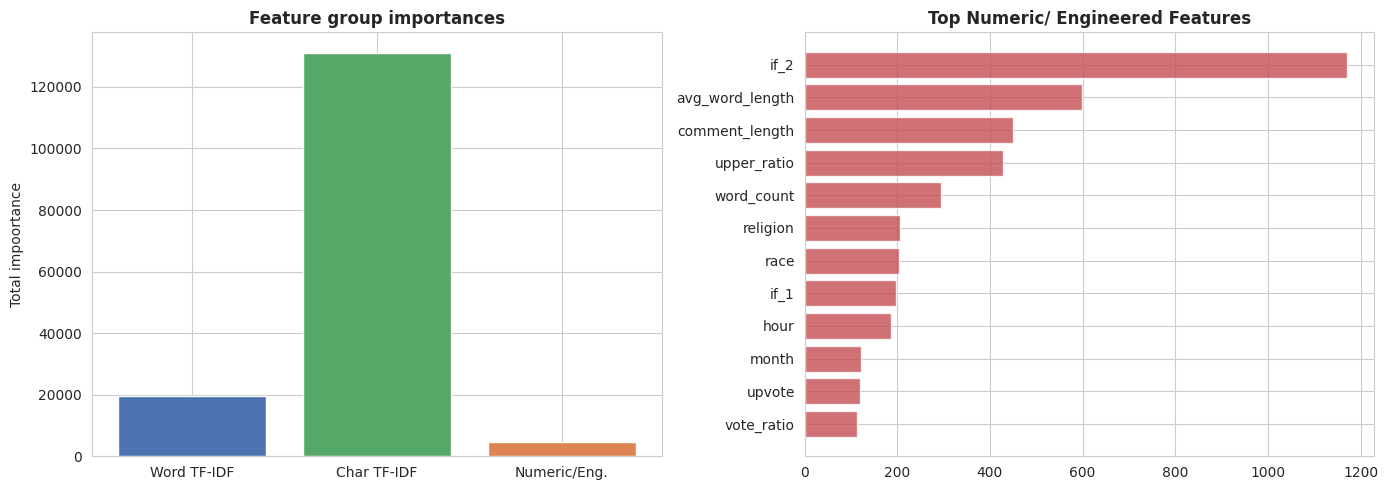

In [51]:
n_word = X_word_tr.shape[1]
n_char = X_char_tr.shape[1]
n_num= X_num_tr.shape[1]
importance =  model.feature_importances_
num_importance = importance[n_word+n_char:]
fig, axes = plt.subplots(1,2,figsize=(14,5))
group_imp={
    'Word TF-IDF': importance[:n_word].sum(),
    'Char TF-IDF': importance[n_word:n_word+n_char].sum(),
    'Numeric/Eng.': importance[n_word+n_char:].sum()
}
axes[0].bar(group_imp.keys(), group_imp.values(),
           color=['#4C72B0','#55A868','#DD8452'])
axes[0].set_title('Feature group importances', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total impoortance')

top_n = np.argsort(num_importance)[::-1][:12]
top_names = [feature_cols[i] if i< len(feature_cols) else f'feat_{i}' for i in top_n]
top_vals = num_importance[top_n]
axes[1].barh(top_names[::-1], top_vals[::-1], color='#C44E52', alpha=0.8)
axes[1].set_title('Top Numeric/ Engineered Features', fontsize=12, fontweight= 'bold')
plt.tight_layout()
plt.show()

==== Out-of-fold Classification Report ====
              precision    recall  f1-score   support

     Class 0       0.98      0.94      0.96    114173
     Class 1       0.75      0.84      0.79     15918
     Class 2       0.87      0.90      0.89     62440
     Class 3       0.65      0.68      0.67      5469

    accuracy                           0.92    198000
   macro avg       0.81      0.84      0.83    198000
weighted avg       0.92      0.92      0.92    198000



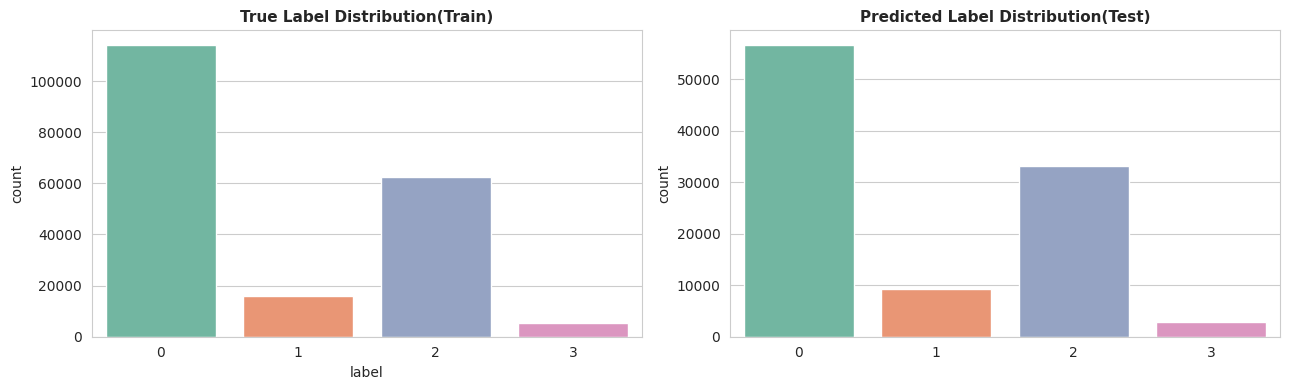

In [52]:
print('==== Out-of-fold Classification Report ====')
print(classification_report(y,val_preds, target_names=[f'Class {i}' for i in range(4)]))

fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.countplot(x=y, ax=axes[0], palette='Set2')
axes[0].set_title('True Label Distribution(Train)', fontsize=11, fontweight='bold')
sns.countplot(x= final_predictions, ax=axes[1], palette='Set2')
axes[1].set_title('Predicted Label Distribution(Test)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

> # **FINAL SUBMISSION**

In [53]:
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [54]:
submission= sample_sub.copy()
submission['label'] = final_predictions.astype(int)
submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')

Submission saved to submission.csv
